In [571]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
from mpmath import mp, taylor, chebyfit, pade, nprint, polyval, cosh,mpf, sqrt
import numpy as np
# import pandas as pd
# from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

In [572]:
mp.pretty = True

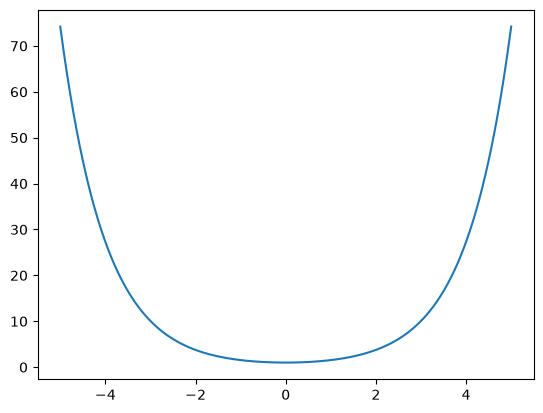

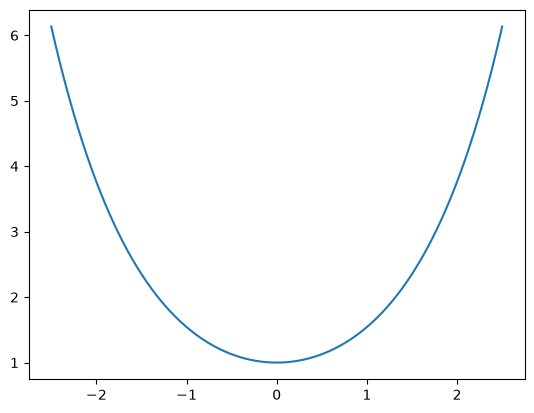

In [573]:
xs = np.linspace(-5, 5, 1000)
ys = np.cosh(xs)
plt.plot(xs, ys)
plt.show()
xs = np.linspace(-2.5, 2.5, 1000)
ys = np.cosh(xs)
plt.plot(xs, ys)
plt.show()




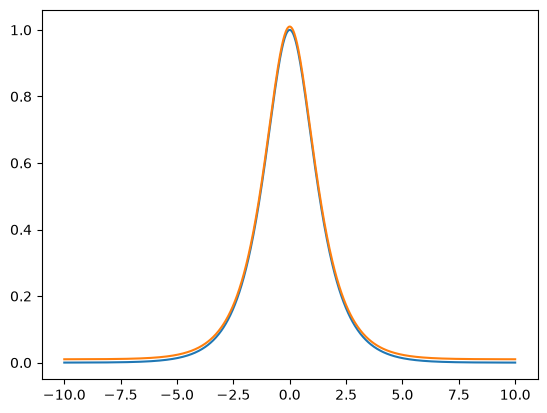

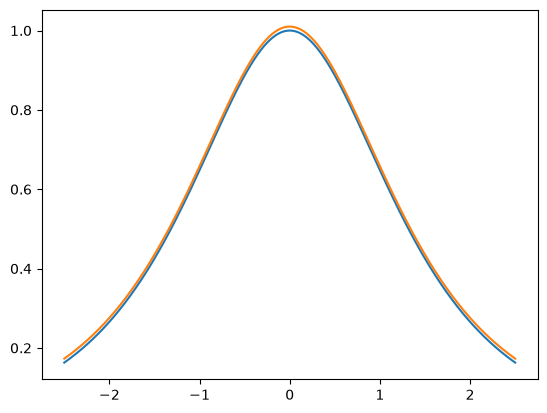

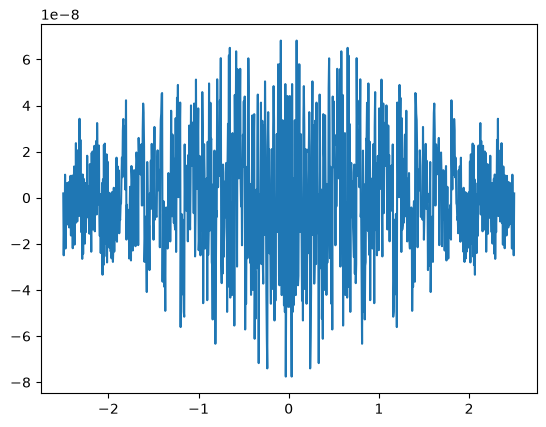

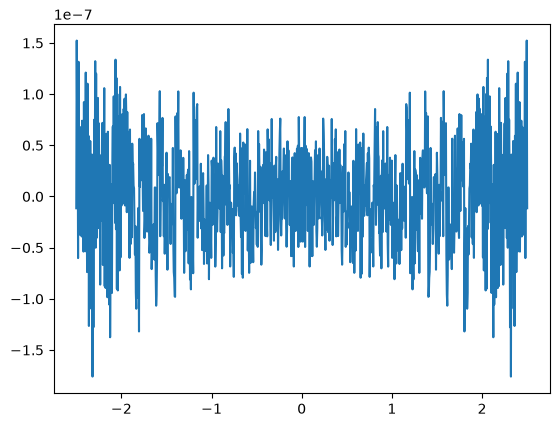

In [574]:
xs = np.linspace(-10, 10, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()


xs = np.linspace(-2.5, 2.5, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()

fs = np.float32(1)/np.cosh(np.float32(xs))
plt.plot(xs, ys-fs)
plt.show()
plt.plot(xs, (fs-ys)/ys)
plt.show()


In [575]:
def et(eta) :
    return 1./cosh(eta)

xmax = mpf(1.5)

polyS, err = chebyfit(et, [-xmax, xmax], 6, error=True)
nprint(poly,12)
nprint(err,12)
print(polyval(poly,0))
nprint(polyval(poly,0.5))
nprint(polyval(poly,1))

def et2(eta) :
    return 1./cosh(sqrt(abs(eta)))


poly2, err2 = chebyfit(et2, [0, xmax*xmax], 9, error=True)
nprint(poly2,12)
nprint(err2,12)
print(polyval(poly2,0)+1)
print(polyval(poly2,0.25)+1)
nprint(polyval(poly2,1)+1)

print()

t = taylor(et, 0, 10)
nprint(t[::-1],12)
t0 = 0.5*xmax
t = taylor(et, t0, 10)
nprint(t[::-1],12)
poly, err = chebyfit(et, [0, xmax], 10, error=True)
nprint(poly,12)
nprint(poly[::-1],12)
nprint(err,12)
p, q = pade(t, 4, 4)
nprint(p)
nprint(q)
nprint(polyval(poly,0))
nprint(polyval(poly,1))
nprint(polyval(t[::-1],0-t0))
nprint(polyval(t[::-1],1-t0))
nprint(polyval(p[::-1],0-t0)/polyval(q[::-1],0-t0))
nprint(polyval(p[::-1],1-t0)/polyval(q[::-1],1-t0))

[0.000570230100504, 0.000320727012212, -0.026104661279, 0.113153474937, -0.190692541186, 0.0585799702529, 0.188861709307, 0.00371174133819, -0.50035979724, 1.35418104215e-5, 0.999999916004]
0.0105403609171
0.999999916004075
0.886819
0.648054
[3.96502730385e-5, -0.000499292050617, 0.00292560602567, -0.0110716399783, 0.0324253941814, -0.0839518905538, 0.208173399054, -0.499986880736, 0.999999818808]
1.76343194226e-7
1.99999981880792
1.88681872171248
1.64805

[-0.0139222332451, 0.0, 0.0343501984127, 0.0, -0.0847222222222, 0.0, 0.208333333333, 0.0, -0.5, 0.0, 1.0]
[-0.000839385056961, 0.00757373714851, -0.00881712199706, -0.00972834425412, 0.0413115474025, -0.0323563956639, -0.0769095794343, 0.210910803931, -0.0746018809577, -0.490582492185, 0.772389673857]
[0.00484524607845, -0.0414213996033, 0.141985913707, -0.223653720345, 0.0820334481706, 0.178636110405, 0.00629169010252, -0.500693216667, 3.04210804006e-5, 0.999999773462]
[0.999999773462, 3.04210804006e-5, -0.500693216667, 0.0062916901

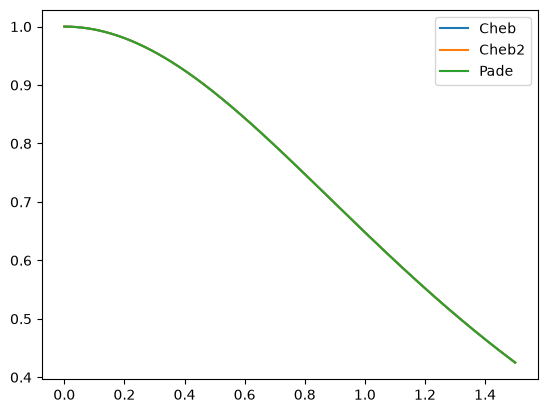

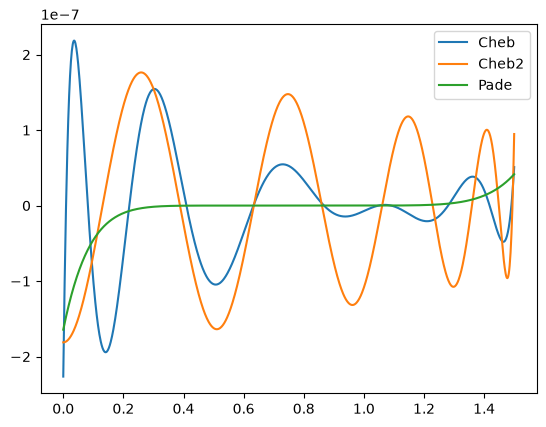

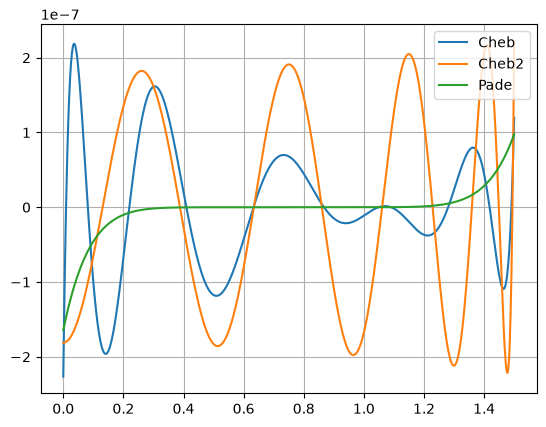

In [576]:
def sollya(x) :
    return 1.00000011920928955078125 + x*x * (-0.500124514102935791015625 + x * (1.97220058180391788482666015625e-3 + x * (0.19547982513904571533203125 + x * (4.45732064545154571533203125e-2 + x * (-0.17418073117733001708984375 + x * (0.1035850942134857177734375 + x * (-2.5238610804080963134765625e-2 + x * 1.987705938518047332763671875e-3)))))))


xs = np.linspace(0, xmax, 1000)
ys = np.fromiter((polyval(poly, xs[n]) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter((polyval(poly2, xs[n]*xs[n]) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter((polyval(t[::-1], xs[n]-t0) for n in range(0,1000)),dtype=np.float64)
ps = np.fromiter((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0) for n in range(0,1000)),dtype=np.float64)
#ss = np.fromiter((sollya(xs[n]) for n in range(0,1000)),dtype=np.float64)

plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
#plt.plot(xs, ss,label='Sollya')
plt.legend(loc='upper right')
plt.show()

ys = np.fromiter(( polyval(poly, xs[n])-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter(( polyval(poly2, xs[n]*xs[n])-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter(( polyval(t[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
ps = np.fromiter(( polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
#ss = np.fromiter((sollya(xs[n])-et(xs[n]) for n in range(0,1000)),dtype=np.float64)

plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
#plt.plot(xs, ss,label='Sollya')
plt.legend(loc='upper right')
plt.show()

ys = np.fromiter(( ((polyval(poly, xs[n])-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter(( ((polyval(poly2, xs[n]*xs[n])-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter(( ((polyval(t[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=mp.float64)
ps = np.fromiter(( ((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)
#ss = np.fromiter(( (sollya(xs[n])-et(xs[n]))/et(xs[n]) for n in range(0,1000)),dtype=np.float64)

plt.grid(True)
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
#plt.plot(xs, ss,label='Sollya')
plt.legend(loc='upper right')
plt.show()

